<a href="https://colab.research.google.com/github/SusanKBioInfo/Comparative-Bacterial-Genome-Analysis/blob/main/bacterial_genome_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install biopython -q
!curl -o ecoli.zip "https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/GCF_000005845.2/download?include_annotation_type=GENOME_FASTA&filename=ecoli.zip"
!curl -o bsub.zip "https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/GCF_000009045.1/download?include_annotation_type=GENOME_FASTA&filename=bsub.zip"
!curl -o saureus.zip "https://api.ncbi.nlm.nih.gov/datasets/v2/genome/accession/GCF_000013425.1/download?include_annotation_type=GENOME_FASTA&filename=saureus.zip"
!unzip -q ecoli.zip -d ecoli_data
!unzip -q bsub.zip -d bsub_data
!unzip -q saureus.zip -d saureus_data
print("All done — genomes downloaded!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 39.5 MB/s eta 0:00:00
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1350k    0 1350k    0     0  1757k      0 --:--:-- --:--:-- --:--:-- 1756k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1222k    0 1222k    0     0  1967k      0 --:--:-- --:--:-- --:--:-- 1965k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  804k    0  804k    0     0  1325k      0 --:--:-- --:--:-- --:--:-- 1327k
All done — genomes downloaded!


In [2]:
import glob
for f in glob.glob("**/*.fna", recursive=True):
    print(f)

saureus_data/ncbi_dataset/data/GCF_000013425.1/GCF_000013425.1_ASM1342v1_genomic.fna
ecoli_data/ncbi_dataset/data/GCF_000005845.2/GCF_000005845.2_ASM584v2_genomic.fna
bsub_data/ncbi_dataset/data/GCF_000009045.1/GCF_000009045.1_ASM904v1_genomic.fna


Loading genomes...
  E. coli: 4,641,652 bp loaded
  B. subtilis: 4,215,606 bp loaded
  S. aureus: 2,821,361 bp loaded

GC Content:
  E. coli: 50.79%
  B. subtilis: 43.51%
  S. aureus: 32.87%

Strand Skew:
  E. coli: GC skew = -0.0011, AT skew = 0.0006
  B. subtilis: GC skew = -0.0023, AT skew = -0.0021
  S. aureus: GC skew = -0.0047, AT skew = -0.0088

Finding ORFs — takes 1-2 minutes, please wait...
  E. coli: 668 ORFs found
  B. subtilis: 551 ORFs found
  S. aureus: 439 ORFs found

── SUMMARY ──

E. coli
  Genome size : 4.64 Mb
  GC content  : 50.79%
  A:24.62%  T:24.59%  G:25.37%  C:25.42%
  GC skew     : -0.0011  |  AT skew: 0.0006
  ORFs (500kbp): 668  |  Mean length: 812 bp

B. subtilis
  Genome size : 4.22 Mb
  GC content  : 43.51%
  A:28.18%  T:28.3%  G:21.71%  C:21.81%
  GC skew     : -0.0023  |  AT skew: -0.0021
  ORFs (500kbp): 551  |  Mean length: 837 bp

S. aureus
  Genome size : 2.82 Mb
  GC content  : 32.87%
  A:33.27%  T:33.86%  G:16.36%  C:16.51%
  GC skew     : -0.004

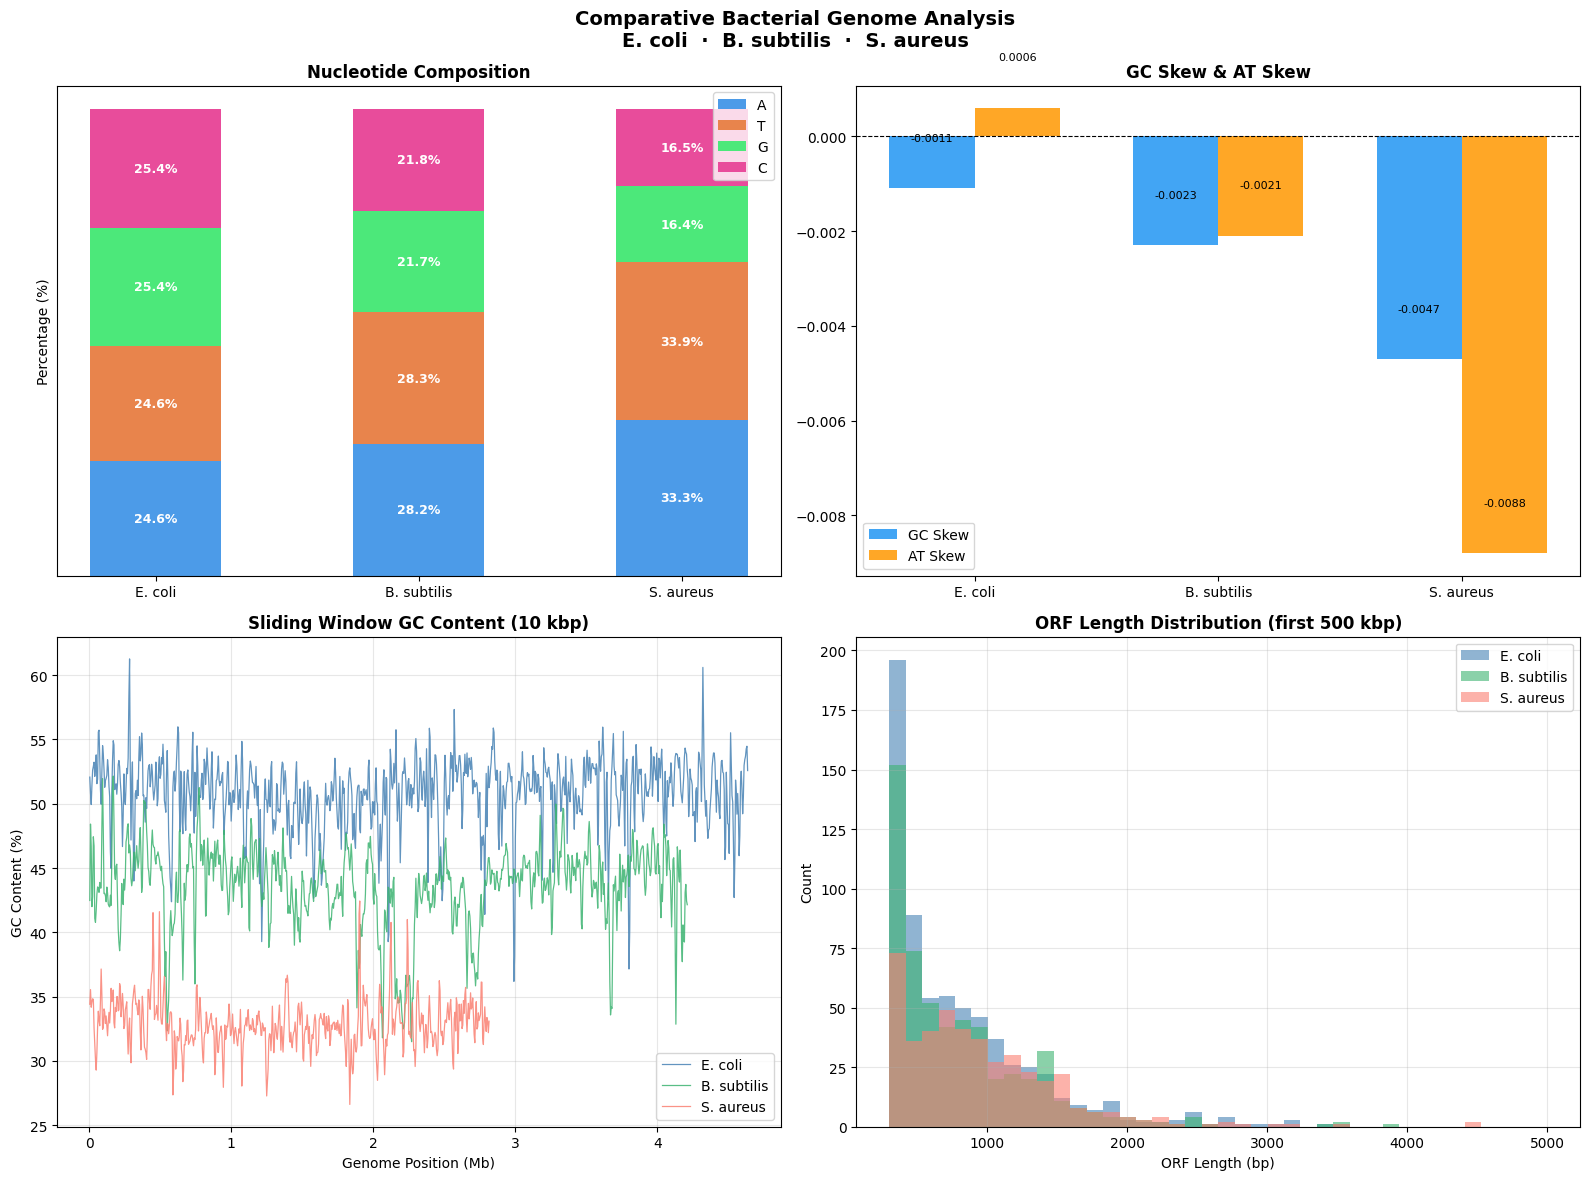


Done! Figure saved.


In [7]:
from Bio import SeqIO
from Bio.SeqUtils import gc_fraction
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import Counter

# ── FILE PATHS ────────────────────────────────────────────────────────────────
ecoli_file   = "ecoli_data/ncbi_dataset/data/GCF_000005845.2/GCF_000005845.2_ASM584v2_genomic.fna"
bsub_file    = "bsub_data/ncbi_dataset/data/GCF_000009045.1/GCF_000009045.1_ASM904v1_genomic.fna"
saureus_file = "saureus_data/ncbi_dataset/data/GCF_000013425.1/GCF_000013425.1_ASM1342v1_genomic.fna"

ORGANISMS = {"E. coli": ecoli_file, "B. subtilis": bsub_file, "S. aureus": saureus_file}
COLORS    = {"E. coli": "steelblue", "B. subtilis": "mediumseagreen", "S. aureus": "salmon"}

# ── LOAD GENOMES ──────────────────────────────────────────────────────────────
def load_genome(filepath):
    seq = ""
    for record in SeqIO.parse(filepath, "fasta"):
        seq += str(record.seq).upper()
    return seq

print("Loading genomes...")
genomes = {name: load_genome(path) for name, path in ORGANISMS.items()}
for name, seq in genomes.items():
    print(f"  {name}: {len(seq):,} bp loaded")

# ── NUCLEOTIDE FREQUENCIES ────────────────────────────────────────────────────
def nucleotide_frequencies(seq):
    counts = Counter(seq)
    total  = sum(counts[b] for b in "ATGC")
    return {b: round(counts[b] / total * 100, 2) for b in "ATGC"}

freq_data = {name: nucleotide_frequencies(seq) for name, seq in genomes.items()}

# ── GC CONTENT ────────────────────────────────────────────────────────────────
gc_values = {name: round(gc_fraction(seq) * 100, 2) for name, seq in genomes.items()}

print("\nGC Content:")
for name, gc in gc_values.items():
    print(f"  {name}: {gc}%")

# ── AT/GC SKEW ────────────────────────────────────────────────────────────────
def compute_skew(seq):
    g, c, a, t = seq.count("G"), seq.count("C"), seq.count("A"), seq.count("T")
    gc_skew = round((g - c) / (g + c), 4) if (g + c) > 0 else 0
    at_skew = round((a - t) / (a + t), 4) if (a + t) > 0 else 0
    return gc_skew, at_skew

skew_data = {name: compute_skew(seq) for name, seq in genomes.items()}

print("\nStrand Skew:")
for name, (gc_sk, at_sk) in skew_data.items():
    print(f"  {name}: GC skew = {gc_sk}, AT skew = {at_sk}")

# ── SLIDING WINDOW GC ─────────────────────────────────────────────────────────
def sliding_window_gc(seq, window=10000, step=5000):
    positions, values = [], []
    for start in range(0, len(seq) - window + 1, step):
        gc = gc_fraction(seq[start:start + window]) * 100
        positions.append(start + window // 2)
        values.append(gc)
    return np.array(positions), np.array(values)

window_data = {name: sliding_window_gc(seq) for name, seq in genomes.items()}

# ── ORF PREDICTION ────────────────────────────────────────────────────────────
STOP_CODONS = {"TAA", "TAG", "TGA"}
MIN_ORF_LEN = 300

def reverse_complement(seq):
    comp = {"A": "T", "T": "A", "G": "C", "C": "G", "N": "N"}
    return "".join(comp.get(b, "N") for b in reversed(seq))

def find_orfs(seq, min_len=MIN_ORF_LEN):
    orfs = []
    for strand_seq in [seq, reverse_complement(seq)]:
        for frame in range(3):
            i, in_orf, orf_start = frame, False, 0
            while i + 3 <= len(strand_seq):
                codon = strand_seq[i:i+3]
                if codon == "ATG" and not in_orf:
                    in_orf, orf_start = True, i
                elif codon in STOP_CODONS and in_orf:
                    if i + 3 - orf_start >= min_len:
                        orfs.append(i + 3 - orf_start)
                    in_orf = False
                i += 3
    return orfs

print("\nFinding ORFs — takes 1-2 minutes, please wait...")
orf_data = {}
for name, seq in genomes.items():
    orfs = find_orfs(seq[:500000])
    orf_data[name] = orfs
    print(f"  {name}: {len(orfs)} ORFs found")

# ── SUMMARY TABLE ─────────────────────────────────────────────────────────────
print("\n── SUMMARY ──")
for name in ORGANISMS:
    seq = genomes[name]
    f = freq_data[name]
    gc_sk, at_sk = skew_data[name]
    orfs = orf_data[name]
    print(f"\n{name}")
    print(f"  Genome size : {len(seq)/1e6:.2f} Mb")
    print(f"  GC content  : {gc_values[name]}%")
    print(f"  A:{f['A']}%  T:{f['T']}%  G:{f['G']}%  C:{f['C']}%")
    print(f"  GC skew     : {gc_sk}  |  AT skew: {at_sk}")
    print(f"  ORFs (500kbp): {len(orfs)}  |  Mean length: {round(np.mean(orfs))} bp")

# ── PLOTS ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Comparative Bacterial Genome Analysis\nE. coli  ·  B. subtilis  ·  S. aureus",
             fontsize=14, fontweight="bold")

orgs = list(ORGANISMS.keys())

# Plot 1: Stacked nucleotide frequencies
ax1 = axes[0, 0]
nuc_colors = {"A": "#4C9BE8", "T": "#E8844C", "G": "#4CE87A", "C": "#E84C9B"}
bottom = np.zeros(len(orgs))
for base in "ATGC":
    vals = [freq_data[o][base] for o in orgs]
    bars = ax1.bar(orgs, vals, bottom=bottom, color=nuc_colors[base], label=base, width=0.5)
    for bar, v, b in zip(bars, vals, bottom):
        ax1.text(bar.get_x() + bar.get_width()/2, b + v/2,
                 f"{v:.1f}%", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    bottom += np.array(vals)
ax1.set_title("Nucleotide Composition", fontweight="bold")
ax1.set_ylabel("Percentage (%)")
ax1.set_yticks([])
ax1.legend()

# Plot 2: GC and AT skew
ax2 = axes[0, 1]
x, w = np.arange(len(orgs)), 0.35
b1 = ax2.bar(x - w/2, [skew_data[o][0] for o in orgs], w, label="GC Skew", color="#2196F3", alpha=0.85)
b2 = ax2.bar(x + w/2, [skew_data[o][1] for o in orgs], w, label="AT Skew", color="#FF9800", alpha=0.85)
for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.001, f"{h:.4f}", ha="center", fontsize=8)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_title("GC Skew & AT Skew", fontweight="bold")
ax2.set_xticks(x)
ax2.set_xticklabels(orgs)
ax2.legend()

# Plot 3: Sliding window GC
ax3 = axes[1, 0]
for name, (positions, values) in window_data.items():
    ax3.plot(positions / 1e6, values, label=name, color=COLORS[name], linewidth=0.9, alpha=0.85)
ax3.set_title("Sliding Window GC Content (10 kbp)", fontweight="bold")
ax3.set_xlabel("Genome Position (Mb)")
ax3.set_ylabel("GC Content (%)")
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: ORF length distribution
ax4 = axes[1, 1]
for name in orgs:
    if orf_data[name]:
        ax4.hist(orf_data[name], bins=40, alpha=0.6, label=name,
                 color=COLORS[name], range=(MIN_ORF_LEN, 5000))
ax4.set_title(f"ORF Length Distribution (first 500 kbp)", fontweight="bold")
ax4.set_xlabel("ORF Length (bp)")
ax4.set_ylabel("Count")
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("bacterial_genome_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print("\nDone! Figure saved.")